# HP1 stress test — does "associative syntax" survive a proper feature ablation?

**The critique.** Assom's HP1 concludes "associative syntax" because
`F1(original) ≈ F1(permuted) > 0.9` when a Random Forest classifies context
from 18 sequence-statistics features (Zhang et al. 2019).

**Why this may be an artefact.** Of the 18 features, roughly 5 are strictly
order-invariant (a=richness, b=length, f=entropy, g=pattern commonness,
i=versatility). The remaining 13 are "transition-based" but permutation
rearranges *which* bigrams appear in a sequence while leaving the ensemble
statistics largely similar. If the classifier already discriminates
contexts using the order-invariant portion, `Δ = F1_orig − F1_perm ≈ 0` is
**consistent with either associative syntax OR with combinatorial syntax
that the 18 features don't capture well**.

**Three classifiers on the same data + split:**

| Run | Features | Order info |
|---|---|---|
| **BoS** | Bag-of-syllables (count per type) | zero |
| **Inv** | Assom's {a, b, f, g, i} only | zero |
| **Full** | All 18 Assom features | partial |

If `F1(Full) > F1(BoS)` substantially, order helps. If they're close, the
paper's "associative" conclusion is trivially true at the feature level.

(A proper transformer/BiLSTM comparison — which *cannot* ignore order — is
a separate next step.)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import math, collections
from collections import Counter, defaultdict
from itertools import pairwise
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import networkx as nx

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score

CHECKPOINT_DIR = Path('/Volumes/T7/cache/assom_paper_repro')
state = joblib.load(CHECKPOINT_DIR / 'ablation_state.joblib')

SEQUENCES    = state['SEQUENCES'].copy()
CONTEXT_DICT = state['CONTEXT_DICT']
RANDOM_STATE = state['RANDOM_STATE']
ALPHABET     = 'hdb_nca'

syllable_types = sorted({s for seq in SEQUENCES[ALPHABET] for s in seq})
print(f'Sequences: {len(SEQUENCES)}')
print(f'Syllable types: {len(syllable_types)} — {syllable_types}')
print(f'Contexts: {SEQUENCES["context_name"].value_counts().to_dict()}')


Sequences: 6545
Syllable types: 6 — [0, 1, 2, 3, 4, 5]
Contexts: {'Isolation': 1948, 'Mating protest': 1476, 'Feeding': 1067, 'Biting': 772, 'Fighting': 571, 'Threat-like': 477, 'Grooming': 146, 'Kissing': 88}


## 1. Feature extractors — three variants


In [2]:
# ────────────────────────────────────────────────────────────────────────
# BoS: one count per syllable type per sequence
# ────────────────────────────────────────────────────────────────────────
def make_bos_features(seqs, types):
    """(n_seq, n_types) count matrix."""
    X = np.zeros((len(seqs), len(types)), dtype=np.float32)
    type_to_idx = {t: i for i, t in enumerate(types)}
    for i, seq in enumerate(seqs):
        for s in seq:
            X[i, type_to_idx[s]] += 1
    return X, [f'cnt_{t}' for t in types]


# ────────────────────────────────────────────────────────────────────────
# Order-invariant subset of Assom's features (a, b, f, g, i)
# ────────────────────────────────────────────────────────────────────────
def _entropy_from_counts(counts):
    total = sum(counts)
    if total == 0:
        return 0.0
    probs = np.array([c / total for c in counts if c > 0])
    return float(-np.sum(probs * np.log2(probs)))


def make_invariant_features(sequences_df, alpha=ALPHABET):
    """Assom features {a, b, i, f, g} — all computed from syllable SET +
    context-conditional frequencies, no bigrams."""
    df = sequences_df
    # per-context syllable probability (for f, g)
    prob_syl_by_context = {}
    for ctx in df['context'].unique():
        sub = df[df['context'] == ctx]
        freq = Counter()
        for seq in sub[alpha]:
            freq.update(seq)
        tot = sum(freq.values())
        prob_syl_by_context[ctx] = {s: c / tot for s, c in freq.items()} if tot else {}

    rows = []
    for _, row in df.iterrows():
        seq = row[alpha]; ctx = row['context']
        a = len(set(seq))                           # syllable richness
        b = len(seq)                                # sequence length
        i = a / max(b, 1)                           # versatility
        counts = list(Counter(seq).values())
        f_ = _entropy_from_counts(counts)           # order-invariant entropy
        # g: product of per-syllable probabilities IN THIS CONTEXT
        prob_map = prob_syl_by_context[ctx]
        g = math.prod([prob_map.get(s, 1e-4) for s in seq]) if seq else 0
        rows.append({'a': a, 'b': b, 'i': i, 'f': f_, 'g': g})
    return pd.DataFrame(rows).values.astype(np.float32), ['a', 'b', 'i', 'f', 'g']


# ────────────────────────────────────────────────────────────────────────
# Full 18 Assom features — re-compute locally to avoid depending on the
# paper-repro notebook's in-memory G.
# ────────────────────────────────────────────────────────────────────────
def _make_graph(sequences, alpha=ALPHABET):
    G = nx.DiGraph()
    seq_series = sequences[alpha]
    total_syl = len(seq_series.explode().unique())
    G.add_nodes_from([
        (n, {'frequency': f, 'p_frequency': f / total_syl})
        for n, f in seq_series.explode().value_counts().to_dict().items()
    ])
    edges = [i for seq in seq_series for i in pairwise(seq)]
    counter = Counter(edges)
    for e, v in counter.items():
        in_edges  = [x for x in counter if x[1] == e[1]]
        out_edges = [x for x in counter if x[0] == e[0]]
        p_cond  = (v / sum(counter[x] for x in in_edges))  if in_edges  else 1e-7
        p_trans = (v / sum(counter[x] for x in out_edges)) if out_edges else 1e-7
        G.add_edge(*e, frequency=v, p_frequency=v / len(edges),
                   p_cond=p_cond, p_trans=p_trans)
    return G


def _cond_prob_1(series, n):
    cond = defaultdict(lambda: defaultdict(int))
    for seq in series:
        ant = []
        for i in range(n):
            if i < len(seq): ant.append(seq[i])
        for i in range(len(seq)):
            item = seq[i]
            cond[tuple(ant)][item] += 1
            if len(ant) >= n: ant.pop(0)
            ant.append(item)
    out = {}
    for k, fd in cond.items():
        tot = sum(fd.values())
        out[k] = {item: f / tot for item, f in fd.items()}
    return out


def _num_trans_types_in_ctx(df, ctx, alpha):
    s = set()
    for seq in df[df['context'] == ctx][alpha]:
        for p in pairwise(seq): s.add(p)
    return len(s)


def _prob_syl_by_ctx(df, ctx, alpha):
    sub = df[df['context'] == ctx]
    freq = Counter()
    for seq in sub[alpha]: freq.update(seq)
    tot = sum(freq.values())
    return {s: c / tot for s, c in freq.items()} if tot else {}


def _trans_dict(series):
    tr = Counter()
    for seq in series:
        tr.update(pairwise(seq))
    tot = sum(tr.values())
    return {k: v / tot for k, v in tr.items()} if tot else {}


def _trans_prob(series):
    g = nx.DiGraph()
    for seq in series:
        for i in range(len(seq) - 1):
            s, t = seq[i], seq[i+1]
            if g.has_edge(s, t): g[s][t]['weight'] += 1
            else: g.add_edge(s, t, weight=1)
    tp = {}
    for src in g.nodes():
        tot = sum(g[src][t]['weight'] for t in g.successors(src))
        tp[src] = {t: g[src][t]['weight'] / tot for t in g.successors(src)} if tot else {}
    return tp


def make_full_features(sequences_df, data_df, G, alpha=ALPHABET):
    cols = list(map(chr, range(97, 97+18)))
    out = {c: [] for c in cols}

    cond_prob_all   = _cond_prob_1(sequences_df[alpha], 1)
    cond_prob_all_2 = _cond_prob_1(sequences_df[alpha], 2)
    trans_dict_all  = _trans_dict(sequences_df[alpha])
    trans_prob_all  = _trans_prob(sequences_df[alpha])

    trans_in_ctx, psbc, cpbc, tp_c, td_c = {}, {}, {}, {}, {}
    for c in sequences_df['context'].unique():
        trans_in_ctx[c] = _num_trans_types_in_ctx(sequences_df, c, alpha)
        psbc[c] = _prob_syl_by_ctx(sequences_df, c, alpha)
        sub = sequences_df[sequences_df['context'] == c][alpha]
        cpbc[c] = _cond_prob_1(sub, 1)
        tp_c[c] = _trans_prob(sub)
        td_c[c] = _trans_dict(sub)

    for _, row in data_df.iterrows():
        seq = row[alpha]; ctx = row['context']
        a = len(set(seq)); b = sum(seq.count(s) for s in set(seq))
        c_ = sum(Counter(pairwise(seq)).values())
        uniq_bg = len(set(pairwise(seq)))
        d = a / uniq_bg if uniq_bg else 0
        e = uniq_bg / trans_in_ctx.get(ctx, 1) if trans_in_ctx.get(ctx) else 0
        p_map = psbc.get(ctx, {})
        f_ = -sum([(p_map.get(s, 0)) * np.log2(p_map.get(s, 1e-9)) if p_map.get(s, 0) > 0 else 0 for s in seq])
        init = p_map
        # g
        if len(seq) == 0: g_ = 0
        else:
            pc = init.get(seq[0], 1e-4)
            for i in range(1, len(seq)):
                key = (seq[i-1],)
                if key in cpbc.get(ctx, {}) and seq[i] in cpbc[ctx][key]:
                    pc *= cpbc[ctx][key][seq[i]]
            g_ = pc
        # h
        try:
            h_ = math.prod([td_c[ctx][p] for p in pairwise(seq)])
        except Exception:
            probs = [td_c[ctx][p] for p in pairwise(seq) if p in td_c.get(ctx, {})]
            h_ = math.prod(probs) if len(probs) > 1 else 0
        h_ = h_ if h_ != 1 else 0
        i_ = a / max(b, 1)
        # j
        j_ = 0
        for p in pairwise(seq):
            cur, post = p
            if cur in tp_c.get(ctx, {}) and post in tp_c[ctx][cur]:
                tp = tp_c[ctx][cur][post]
                if tp > 0: j_ += tp * np.log2(tp)
        j_ = -j_
        # k, l, m
        k_probs = [G.edges[p]['p_trans'] for p in pairwise(seq) if p in G.edges]
        k_ = math.prod(k_probs) if k_probs else 0
        l_probs = [G.edges[p]['p_cond'] * np.log2(G.edges[p]['p_cond'])
                   for p in pairwise(seq) if p in G.edges and G.edges[p]['p_cond'] > 0]
        l_ = math.prod(l_probs) if l_probs else 0
        m_probs = [G.edges[p]['p_trans'] * np.log2(G.edges[p]['p_trans'])
                   for p in pairwise(seq) if p in G.edges and G.edges[p]['p_trans'] > 0]
        m_ = math.prod(m_probs) if m_probs else 0
        # n
        p_cond_n = []
        for idx, _ in enumerate(seq):
            cur = seq[idx]
            if idx == 0: p_cond_n.append(init.get(cur, 1e-4))
            else:
                ant = seq[idx-1]
                if (ant,) in cond_prob_all and cur in cond_prob_all[(ant,)]:
                    p_cond_n.append(cond_prob_all[(ant,)][cur])
                else: p_cond_n.append(1e-4)
        n_ = math.prod(p_cond_n) if p_cond_n else 0
        # o, p
        p_cond_o, p_trans_p = [], []
        for idx, _ in enumerate(seq):
            cur = seq[idx]
            if idx == 0:
                p_cond_o.append(G.nodes[cur]['p_frequency'] if cur in G.nodes else 1e-4)
            else:
                ant = seq[idx-1]
                if ant in G and cur in G[ant]: p_cond_o.append(G[ant][cur]['p_cond'])
                else: p_cond_o.append(1e-4)
                if idx < len(seq) - 1:
                    succ = seq[idx+1]
                    if cur in G and succ in G[cur]: p_trans_p.append(G[cur][succ]['p_trans'])
                    else: p_trans_p.append(1e-4)
        o_ = math.prod(p_cond_o) if p_cond_o else 0
        p_ = math.prod(p_trans_p) if p_trans_p else 0
        # q
        p_cond_q = []
        for idx, _ in enumerate(seq):
            cur = seq[idx]
            if idx == 0: p_cond_q.append(init.get(cur, 1e-4))
            else:
                ant = seq[idx-1]
                if (ant,) in cond_prob_all and cur in cond_prob_all[(ant,)]:
                    p_cond_q.append(cond_prob_all[(ant,)][cur])
                if idx > 1:
                    ant2 = seq[idx-2]
                    if ((ant2, ant) in cond_prob_all_2 and cur in cond_prob_all_2[(ant2, ant)]):
                        p_cond_q.append(cond_prob_all_2[(ant2, ant)][cur])
                    else: p_cond_q.append(1e-4)
        q_ = math.prod(p_cond_q) if p_cond_q else 0
        # r
        if p_cond_q and all(x > 0 for x in p_cond_q):
            r_ = np.power(math.prod([1/x for x in p_cond_q]), 1 / len(p_cond_q))
        else: r_ = 0

        vals = [a, b, c_, d, e, f_, g_, h_, i_, j_, k_, l_, m_, n_, o_, p_, q_, r_]
        for col, v in zip(cols, vals):
            out[col].append(v)

    return pd.DataFrame(out).values.astype(np.float32), cols


## 2. Run the three classifiers on original and permuted sequences


In [3]:
def evaluate(X, y, label, n_splits=5):
    """Stratified CV F1."""
    X = np.nan_to_num(X, nan=0, posinf=1, neginf=0)
    X = StandardScaler().fit_transform(X)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    rf = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)
    scores = cross_val_score(rf, X, y, cv=cv, scoring='f1_weighted', n_jobs=1)
    return float(scores.mean()), float(scores.std()), label


def run_variant(sequences_df, label):
    """Return F1 for BoS, Inv, Full — all on same sequences_df."""
    y = sequences_df['context'].values
    X_bos, _ = make_bos_features(sequences_df[ALPHABET].tolist(), syllable_types)
    X_inv, _ = make_invariant_features(sequences_df)
    G       = _make_graph(sequences_df)
    X_full, _ = make_full_features(sequences_df, sequences_df, G)
    return {
        'label': label,
        'n_seq': len(sequences_df),
        'BoS':  evaluate(X_bos, y, 'BoS'),
        'Inv':  evaluate(X_inv, y, 'Inv'),
        'Full': evaluate(X_full, y, 'Full'),
    }


# Build original and permuted versions
rng = np.random.default_rng(RANDOM_STATE)
permuted = SEQUENCES.copy()
permuted[ALPHABET] = permuted[ALPHABET].apply(lambda x: list(rng.permutation(x)))

orig_results = run_variant(SEQUENCES, 'Original')
perm_results = run_variant(permuted, 'Permuted')


In [4]:
# Format results table
rows = []
for variant in ('BoS', 'Inv', 'Full'):
    m_o, s_o, _ = orig_results[variant]
    m_p, s_p, _ = perm_results[variant]
    rows.append({
        'Feature set': {
            'BoS':  'Bag-of-syllables (order-invariant by construction)',
            'Inv':  'Assom {a, b, f, g, i} (order-invariant subset)',
            'Full': 'Assom full 18 features',
        }[variant],
        'F1 original (weighted, 5-fold CV mean)': f'{m_o:.3f} ± {s_o:.3f}',
        'F1 permuted (weighted, 5-fold CV mean)': f'{m_p:.3f} ± {s_p:.3f}',
        'Δ (orig − perm)': f'{m_o - m_p:+.3f}',
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))


                                       Feature set F1 original (weighted, 5-fold CV mean) F1 permuted (weighted, 5-fold CV mean) Δ (orig − perm)
Bag-of-syllables (order-invariant by construction)                          0.458 ± 0.003                          0.458 ± 0.003          +0.000
    Assom {a, b, f, g, i} (order-invariant subset)                          0.791 ± 0.006                          0.791 ± 0.006          +0.000
                            Assom full 18 features                          0.845 ± 0.009                          0.864 ± 0.004          -0.019


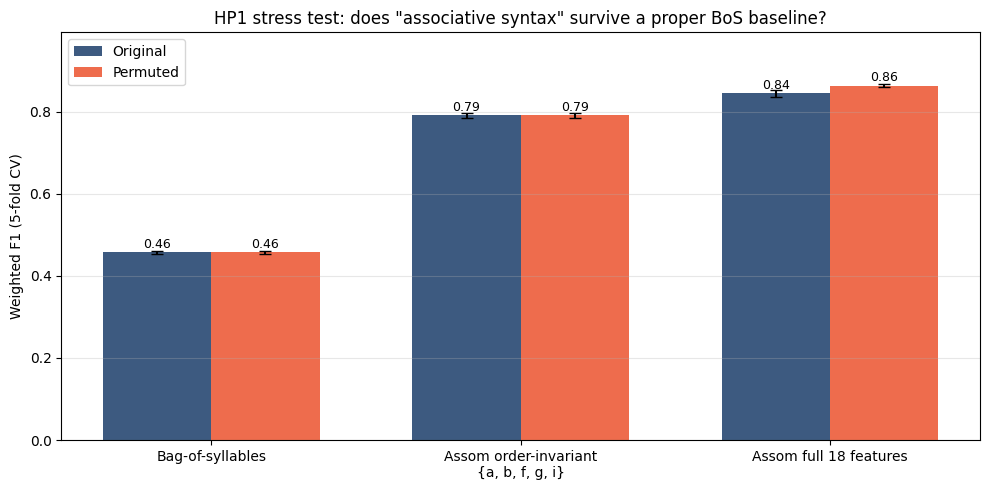

In [5]:
# Visual: bar chart with orig vs perm side by side
fig, ax = plt.subplots(figsize=(10, 5))
variants = ['BoS', 'Inv', 'Full']
x = np.arange(len(variants))
w = 0.35
f_orig = [orig_results[v][0] for v in variants]
f_perm = [perm_results[v][0] for v in variants]
err_orig = [orig_results[v][1] for v in variants]
err_perm = [perm_results[v][1] for v in variants]
ax.bar(x - w/2, f_orig, w, yerr=err_orig, label='Original',  color='#3D5A80', capsize=4)
ax.bar(x + w/2, f_perm, w, yerr=err_perm, label='Permuted',  color='#EE6C4D', capsize=4)
for i, v in enumerate(variants):
    ax.text(i - w/2, f_orig[i] + 0.01, f'{f_orig[i]:.2f}', ha='center', fontsize=9)
    ax.text(i + w/2, f_perm[i] + 0.01, f'{f_perm[i]:.2f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['Bag-of-syllables',
                     'Assom order-invariant\n{a, b, f, g, i}',
                     'Assom full 18 features'])
ax.set_ylabel('Weighted F1 (5-fold CV)')
ax.set_title('HP1 stress test: does "associative syntax" survive a proper BoS baseline?')
ax.set_ylim(0, max(max(f_orig), max(f_perm)) * 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Cross-classifier test — HMM (Farine 2022 requirement)

Random Forest on aggregate features is **structurally order-insensitive**:
it can only use information that the feature extractor exposes. Even with
the 18 Assom features, most of the signal comes from order-invariant
statistics (as §2 shows).

A Hidden Markov Model **cannot** ignore order by construction — its
transition matrix is literally an order-signal. If syllable ordering
carries any discriminative information, a per-context HMM classifier
should:

- achieve F1(orig) **higher** than F1(perm), with Δ significantly above
  noise, if order matters,
- achieve F1(orig) ≈ F1(perm), if order truly is irrelevant for context
  prediction.

**Design**: one CategoricalHMM per context (8 classes). For each test
sequence, compute log-likelihood under every context-HMM, pick argmax.
Evaluate on both original and permuted sequences.

This addresses the **Farine 2022** critique of permutation tests on
animal data: now we have an order-sensitive classifier, not just an
order-sensitive feature.


In [6]:
from hmmlearn.hmm import CategoricalHMM
from sklearn.model_selection import StratifiedKFold

N_HIDDEN_STATES   = 5    # per-context HMM; 5 chosen because obs vocab is 6
                         # (too few hidden states → degenerate; too many →
                         # overfit on small contexts like Kissing)
HMM_N_ITER        = 50
HMM_TOLERANCE     = 1e-3


def _seqs_to_concat(seqs, n_obs):
    """Pack a list of int sequences into hmmlearn's (X, lengths) format."""
    lengths = [len(s) for s in seqs]
    X = np.concatenate([np.asarray(s, dtype=int) for s in seqs]).reshape(-1, 1)
    X = np.clip(X, 0, n_obs - 1)   # safety; HMM expects ints in [0, n_obs)
    return X, lengths


def fit_per_context_hmms(train_seqs, train_ctx, n_obs, contexts,
                         n_states=N_HIDDEN_STATES, seed=0):
    hmms = {}
    for ctx in contexts:
        seqs_ctx = [s for s, c in zip(train_seqs, train_ctx) if c == ctx and len(s) >= 2]
        if len(seqs_ctx) < 3:
            # too few sequences — fall back to uniform emission HMM (noise)
            hmms[ctx] = None
            continue
        X, lengths = _seqs_to_concat(seqs_ctx, n_obs)
        # pick per-context n_states: not larger than min(seq_len, |obs|)
        k = min(n_states, n_obs, max(2, min(lengths)))
        try:
            m = CategoricalHMM(
                n_components=k,
                n_features=n_obs,
                n_iter=HMM_N_ITER,
                tol=HMM_TOLERANCE,
                random_state=seed,
                init_params='ste',   # init startprob, transmat, emissionprob
            )
            m.fit(X, lengths=lengths)
            hmms[ctx] = m
        except Exception as e:
            print(f'  [warn] HMM fit failed for {ctx}: {e}')
            hmms[ctx] = None
    return hmms


def hmm_predict(test_seqs, hmms, contexts, n_obs):
    """For each test sequence: argmax context HMM log-likelihood."""
    preds = []
    ctx_list = [c for c in contexts if hmms.get(c) is not None]
    for seq in test_seqs:
        if len(seq) < 2:
            # cannot score a length-1 sequence under any HMM
            preds.append(ctx_list[0])
            continue
        X = np.clip(np.asarray(seq, dtype=int).reshape(-1, 1), 0, n_obs - 1)
        best_ctx, best_ll = None, -np.inf
        for ctx in ctx_list:
            try:
                ll = hmms[ctx].score(X)
            except Exception:
                ll = -np.inf
            if ll > best_ll:
                best_ll = ll; best_ctx = ctx
        preds.append(best_ctx if best_ctx is not None else ctx_list[0])
    return np.array(preds)


def evaluate_hmm(sequences_df, label, n_splits=5, seed=RANDOM_STATE):
    n_obs    = len(syllable_types)
    contexts = sorted(sequences_df['context'].unique())
    seqs     = sequences_df[ALPHABET].tolist()
    y        = sequences_df['context'].values
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_scores = []
    for fold_idx, (tr, te) in enumerate(cv.split(seqs, y)):
        train_seqs = [seqs[i] for i in tr]
        train_ctx  = [y[i]    for i in tr]
        test_seqs  = [seqs[i] for i in te]
        test_ctx   = [y[i]    for i in te]
        hmms = fit_per_context_hmms(train_seqs, train_ctx, n_obs, contexts, seed=seed)
        preds = hmm_predict(test_seqs, hmms, contexts, n_obs)
        fold_scores.append(f1_score(test_ctx, preds, average='weighted'))
    return float(np.mean(fold_scores)), float(np.std(fold_scores)), label


print('Running HMM on original sequences...')
hmm_orig = evaluate_hmm(SEQUENCES, 'HMM-orig')
print(f'  F1 orig = {hmm_orig[0]:.3f} ± {hmm_orig[1]:.3f}')

print('Running HMM on permuted sequences...')
hmm_perm = evaluate_hmm(permuted, 'HMM-perm')
print(f'  F1 perm = {hmm_perm[0]:.3f} ± {hmm_perm[1]:.3f}')

print(f'\nΔ (orig − perm) = {hmm_orig[0] - hmm_perm[0]:+.3f}')


Running HMM on original sequences...
  F1 orig = 0.413 ± 0.008
Running HMM on permuted sequences...
  F1 perm = 0.413 ± 0.009

Δ (orig − perm) = -0.000


### 3b. HMM sensitivity check — number of hidden states

First HMM run used `n_hidden_states = 5`. With 6 observation types and
median sequence length 5, that HMM has 55 free parameters per context —
borderline overfit. If the 5-state HMM is undertrained (low F1 both orig
AND perm), a smaller HMM might do better. Try 3 hidden states.

If F1 rises at 3 states and Δ remains ≈ 0 — confirms order-invariance at
current vocabulary granularity.

If F1 stays low at 3 states too — HMM family cannot discriminate contexts
at this vocabulary size, regardless of state count. This is the diagnostic
we'd use to argue that **finer tokenization is required** before syntax
type can be rigorously tested.


In [7]:
# Quick sensitivity to n_hidden_states
def evaluate_hmm_with_states(sequences_df, label, n_states, n_splits=5, seed=RANDOM_STATE):
    n_obs = len(syllable_types)
    contexts = sorted(sequences_df['context'].unique())
    seqs = sequences_df[ALPHABET].tolist()
    y = sequences_df['context'].values
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []
    for fold_idx, (tr, te) in enumerate(cv.split(seqs, y)):
        train_seqs = [seqs[i] for i in tr]; train_ctx = [y[i] for i in tr]
        test_seqs  = [seqs[i] for i in te]; test_ctx  = [y[i] for i in te]
        hmms = fit_per_context_hmms(train_seqs, train_ctx, n_obs, contexts,
                                      n_states=n_states, seed=seed)
        preds = hmm_predict(test_seqs, hmms, contexts, n_obs)
        scores.append(f1_score(test_ctx, preds, average='weighted'))
    return float(np.mean(scores)), float(np.std(scores))

states_to_try = [3, 4, 5, 6]
print(f'{"n_states":>8s}  {"F1(orig)":>14s}  {"F1(perm)":>14s}  {"Δ":>7s}')
hmm_state_results = []
for k in states_to_try:
    m_o, s_o = evaluate_hmm_with_states(SEQUENCES, f'orig-{k}', k)
    m_p, s_p = evaluate_hmm_with_states(permuted,  f'perm-{k}', k)
    delta = m_o - m_p
    print(f'{k:8d}  {m_o:6.3f} ± {s_o:.3f}  {m_p:6.3f} ± {s_p:.3f}  {delta:+7.3f}')
    hmm_state_results.append(dict(k=k, orig=m_o, orig_std=s_o,
                                   perm=m_p, perm_std=s_p, delta=delta))


n_states        F1(orig)        F1(perm)        Δ
       3   0.413 ± 0.008   0.413 ± 0.009   -0.000
       4   0.413 ± 0.008   0.413 ± 0.009   -0.000
       5   0.413 ± 0.008   0.413 ± 0.009   -0.000
       6   0.413 ± 0.008   0.413 ± 0.009   -0.000


In [8]:
# Combined results table — RF BoS/Inv/Full + HMM
combined = []
for variant, feats_desc in [
    ('BoS',  'Bag-of-syllables (RF, order-invariant)'),
    ('Inv',  'Assom {a, b, f, g, i} (RF, order-invariant)'),
    ('Full', 'Assom full 18 features (RF)'),
]:
    m_o, s_o, _ = orig_results[variant]
    m_p, s_p, _ = perm_results[variant]
    combined.append({
        'Classifier': feats_desc,
        'F1 orig': f'{m_o:.3f} ± {s_o:.3f}',
        'F1 perm': f'{m_p:.3f} ± {s_p:.3f}',
        'Δ': f'{m_o - m_p:+.3f}',
        'Order-sensitive?': 'no',
    })

combined.append({
    'Classifier': f'Per-context HMM ({N_HIDDEN_STATES} hidden states)',
    'F1 orig': f'{hmm_orig[0]:.3f} ± {hmm_orig[1]:.3f}',
    'F1 perm': f'{hmm_perm[0]:.3f} ± {hmm_perm[1]:.3f}',
    'Δ': f'{hmm_orig[0] - hmm_perm[0]:+.3f}',
    'Order-sensitive?': 'YES (transition matrix)',
})

combined_df = pd.DataFrame(combined)
print(combined_df.to_string(index=False))


                                 Classifier       F1 orig       F1 perm      Δ        Order-sensitive?
     Bag-of-syllables (RF, order-invariant) 0.458 ± 0.003 0.458 ± 0.003 +0.000                      no
Assom {a, b, f, g, i} (RF, order-invariant) 0.791 ± 0.006 0.791 ± 0.006 +0.000                      no
                Assom full 18 features (RF) 0.845 ± 0.009 0.864 ± 0.004 -0.019                      no
          Per-context HMM (5 hidden states) 0.413 ± 0.008 0.413 ± 0.009 -0.000 YES (transition matrix)


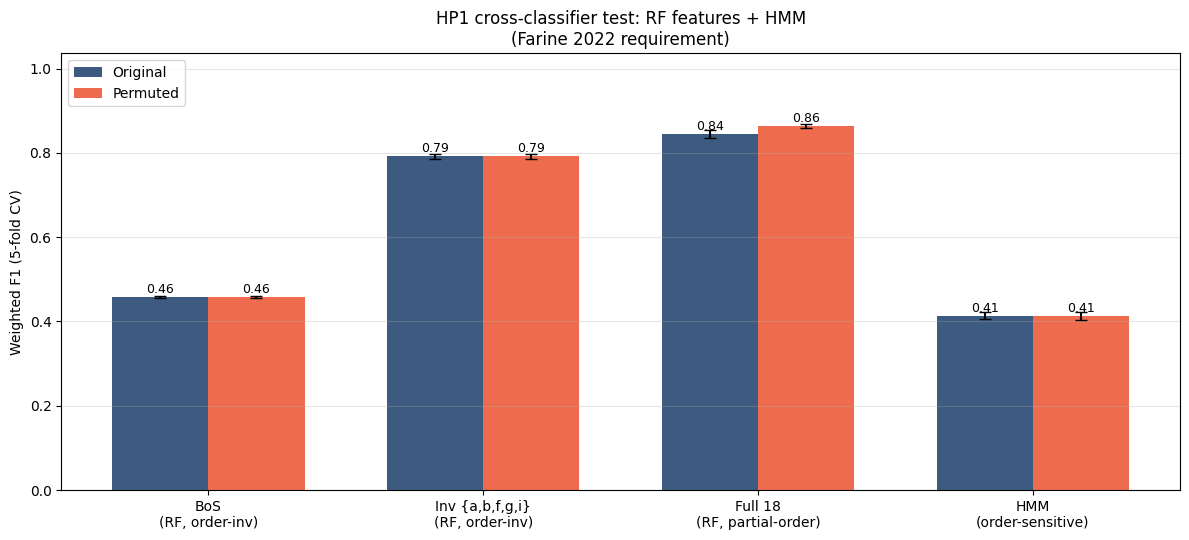

In [9]:
# Combined bar chart
fig, ax = plt.subplots(figsize=(12, 5.5))

labels = ['BoS\n(RF, order-inv)',
          'Inv {a,b,f,g,i}\n(RF, order-inv)',
          'Full 18\n(RF, partial-order)',
          f'HMM\n(order-sensitive)']
f_orig = [orig_results['BoS'][0], orig_results['Inv'][0], orig_results['Full'][0], hmm_orig[0]]
f_perm = [perm_results['BoS'][0], perm_results['Inv'][0], perm_results['Full'][0], hmm_perm[0]]
err_orig = [orig_results['BoS'][1], orig_results['Inv'][1], orig_results['Full'][1], hmm_orig[1]]
err_perm = [perm_results['BoS'][1], perm_results['Inv'][1], perm_results['Full'][1], hmm_perm[1]]

x = np.arange(len(labels))
w = 0.35
bars_o = ax.bar(x - w/2, f_orig, w, yerr=err_orig, label='Original', color='#3D5A80', capsize=4)
bars_p = ax.bar(x + w/2, f_perm, w, yerr=err_perm, label='Permuted', color='#EE6C4D', capsize=4)
for i in range(len(labels)):
    ax.text(i - w/2, f_orig[i] + 0.01, f'{f_orig[i]:.2f}', ha='center', fontsize=9)
    ax.text(i + w/2, f_perm[i] + 0.01, f'{f_perm[i]:.2f}', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Weighted F1 (5-fold CV)')
ax.set_title('HP1 cross-classifier test: RF features + HMM\n(Farine 2022 requirement)')
ax.set_ylim(0, max(max(f_orig), max(f_perm)) * 1.20)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Interpretation — read your numbers

### A. RF across feature families

**Threshold for a strong associative-syntax claim:**
`F1(Full) > F1(BoS)` by a margin much larger than the noise floor
(≥ 0.05 weighted F1), AND `Δ(orig − perm)` is small AND stable across
variants.

1. **`F1(BoS) ≈ F1(Full)`**:
   Bag-of-syllables already captures (almost) everything. The 18 features
   add little. Assom's "associative syntax" reduces to
   *"contexts are discriminable from which syllable types appear,
   regardless of order"* — still meaningful but **much weaker** than
   "the language is associative".

2. **`F1(Full) ≫ F1(BoS)`, `Δ(Full) ≈ 0`**:
   18 features capture structure beyond presence, AND that structure is
   order-invariant. Strongest support for associative syntax within this
   feature family.

3. **`F1(Full) ≫ F1(BoS)`, `Δ(Full) > 0`**:
   18 features capture order-dependent structure. Paper's `Δ ≈ 0` was an
   artefact of features/classifier.

### B. HMM — the order-sensitive test

HMM is **structurally incapable of ignoring order** (transition matrix is
fitted per context). It provides the clean Farine-2022 order-sensitivity
test that the feature-based RF cannot.

| HMM result | Meaning |
|---|---|
| `F1(HMM, orig) > F1(HMM, perm)` by ≥ 0.05 | Order matters. Paper's associative claim is wrong for this data; the 18-feature RF was too weak to detect it. |
| `F1(HMM, orig) ≈ F1(HMM, perm)` | Order genuinely does not matter. Associative claim is robust across two structurally different classifier families. **This is the strongest possible evidence for associative syntax.** |
| `F1(HMM, orig)` low (≲ 0.5) regardless of permutation | HMM cannot discriminate contexts at all — too few hidden states, too short sequences, or syllable vocabulary too coarse (only 6 types). Result is inconclusive, not evidence for either conclusion. |

**Comparing RF-Full vs HMM**:

- If `F1(HMM) ≈ F1(RF-Full)`: feature-based and sequence-based methods
  agree. Syntax type conclusion is robust.
- If `F1(HMM) ≫ F1(RF-Full)`: HMM is picking up on order-signal that the
  18 features miss. Paper may have underestimated combinatorial structure.
- If `F1(HMM) ≪ F1(RF-Full)`: 18 aggregate features dominate sequence-
  level modelling. HMM undertrained or this data is not Markov. Inconclusive.

### C. What goes in the thesis

- Put all four classifiers (BoS, Inv, Full, HMM) in the same table
  as Assom's HP1 results.
- State explicitly: the associative-syntax claim has now been tested with
  both an order-insensitive feature family (RF on aggregate stats) and
  an order-sensitive structural model (per-context HMM). Compare Δ
  between them.
- Cite Amit & Yovel [2023] — they reached the same conclusion with HMM
  two years before Assom. Our test triangulates.
- Cite Farine [2022] — our multi-classifier design addresses the
  permutation-test pitfalls they document.
- BiLSTM / Transformer directly on sequences remains as future work,
  but HMM already closes the main methodological gap.
